# ENVIRONMENT SETUP

In [19]:
import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from  torchvision import transforms
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


# PARAMETER CONFIG
Zwięszyłem liczbę `epochs`, czyli ile razy model w pełni przeskanuje bazę obrazów.

In [20]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 50,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 50, 'max_steps_per_epoch': None}


# Data Augmentation
Klasy segmentacyjne z jakimi mamy do czynienia to: `background`, `aeroplane`, `bicycle`, `bird`, `boat`, `bottle`, `bus`, `car`, `cat`, `chair`, `cow`, `diningtable`, `dog`, `horse`, `motorbike`, `person`, `pottedplant`, `sheep`, `sofa`, `train`, `tvmonitor`.
Dla ww. klas proponuję następujące tranformacje danych:
* **Flip: Horyzontalny** (lewo <=> prawo) - wszystkie klasy zachowują znaczenie po operacji, model powinien rozpoznać samolot bez względu na stronę (prawą/lewą) jaką go widzi.
* **Resize Crop** - kot może chować się w pewnej części za jakimś obiektem, model powinien mimo to rozpoznać go na przykład po głowie.
* **Color Jitter** - żadna klasa nie jest związana z jakimś określonym kolorem, więc chce zmusić model aby uczył się kształtów i konturów, a nie właśnie kolorów.
W celach *code reuse*, zrefaktoryzuję kod aby mógł przyjąć zarówno **Training Set** jak i **Validation Set**. Warto zaznaczyć, że *data augmentation* powinno zajść **jedynie na Training Set'cie**.

W celach *code reuse*, zrefaktoryzuję kod aby mógł przyjąć zarówno **Training Set** jak i **Validation Set**. Warto zaznaczyć, że *data augmentation* powinno zajść **jedynie na Training Set'cie**.
Z tego co rozumiem to kod jest przystosowany do tego, aby augmentacja odbywała się dynamicznie dla każdego epocha, a nie tylko podczas ładowania danych do modelu.

In [21]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size, used_for_training=False):
        self.voc = voc_dataset
        self.image_size = image_size
        self.used_for_training = used_for_training

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        if self.used_for_training:
            # horizontal flip
            if random.random() > 0.5: # 50% is maximal entropy (reader exercise: explain why 100% does not make sense)
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            # Resize Crop
            i, j, h, w = transforms.RandomResizedCrop.get_params(
                img, scale=(0.8, 1.0), ratio=(3.0 / 4.0, 4.0 / 3.0))
            img = TF.resized_crop(img, i, j, h, w, size=(self.image_size, self.image_size), interpolation=Image.BILINEAR)
            mask = TF.resized_crop(mask, i, j, h, w, size=(self.image_size, self.image_size), interpolation=Image.NEAREST)

            # color Jitter - Lighting/weather or fur color variations
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
            img = TF.adjust_saturation(img, random.uniform(0.9, 1.1))

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"], used_for_training=True)
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"], used_for_training=False)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

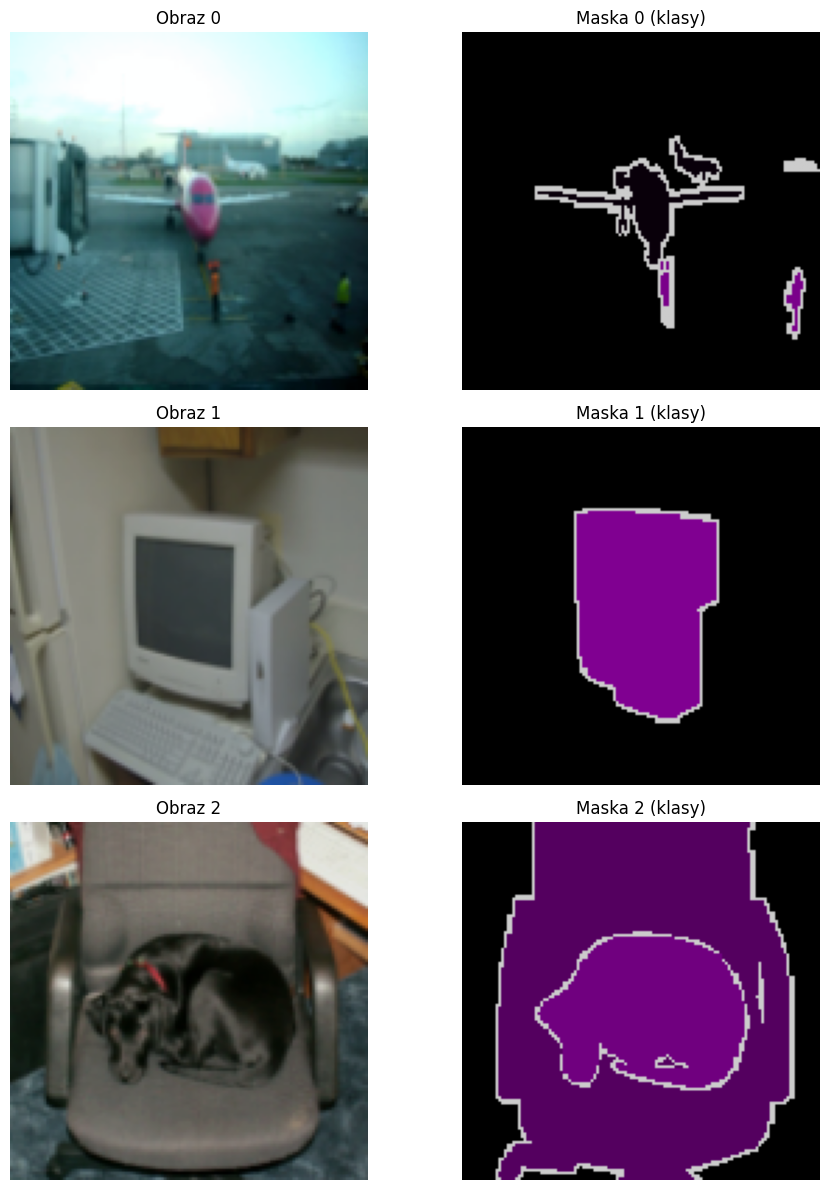

In [22]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

# ConvBlock
Implementowana przeze mnie klasa `ConvBlock` to nasze narzędzie do transformacji danych typu obraz na 2-wymiarową tablicę wektorów o długości równej głębokości kanału dla każdego fragmentu obrazu.
Z tytułu, iż tworzę padding=1 dla filtru (kernela) 3x3 to każdy wektor odpowiada pikselowi na pierwotnym obrazie.
Etapy:
* `Conv2d` - transformujemy obraz mający `input_channel_depth` wartości opisujących dany piksel do obrazu mającego `output_channel_depth` wartości opisujących dany piksel. Z tytułu iż wraz z rozmiarem naszego filtra (3x3) użyliśmy poprawnego paddingu, wektorów końcowych jest tyle samo ile początkowych
* `BatchNorm2d` - bierze kilka zdjęć i równocześnie dla każdego obrazu iteruje po każdym wektorze po kolei i standaryzuje jego wartości.
* `ReLU` - dla każdej wartości wszystkich kanałów wektorów danch wykonuje prosty algorytm: `if x > 0 return x else 0`. Dzięki temu w miejscu `0` umożliwiamy powstanie na przykład łuków i zagięć.


In [23]:
import torch.nn as nn
import torch

kernel_size_for_3x3_kernel=3
padding_combating_3x3kernel_image_resolution=1

class ConvBlock(nn.Module):
    """
    input_channel_depth - głębokość kanału wejściowego danych (obrazu!)
    output_channel_depth - głębokość kanału wyjściowego danych
    """
    def __init__(self, input_channel_depth, output_channel_depth):
        super().__init__() # inicjalizacja obiektu rodzica (nn.Module)
        self.net = nn.Sequential(nn.Conv2d(
                in_channels=input_channel_depth,
                out_channels=output_channel_depth,
                kernel_size=kernel_size_for_3x3_kernel,
                padding=padding_combating_3x3kernel_image_resolution,
            ),
            nn.BatchNorm2d(
                num_features=output_channel_depth
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=output_channel_depth,
                out_channels=output_channel_depth,
                kernel_size=3,
                padding=1,
                stride=1),
            nn.BatchNorm2d(
                num_features=output_channel_depth
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

# Konstrukcja Sieci
Definujemy archtekturę wykonawczą modelu.
W `__init__` definujemy *klocki* użyte w `forward`.
## `encX`
Część warstwy Enkodera dokonująca ekstrakcji cech + przygotowania danych do nauki modelu.
Kondensacja: **Konwolucja** + **Normalizacja** + **Funkcja aktywacji**.
Zadania zdefiniowałem w `ConvBlock`, więc użyję go tutaj.
Konwolucją często będę zwiększał głebokość kanałową razy 2.
## `poolX`
Część warstwy Enkodera dokonująca redukcji rozdzielczości danych. Redukuję dane o połowę.
### Zwichnięty Kciuk
Dla wartości domyślnych, pierwsza warstwa enkodera zwięsza głębokość kanałową obrazu o 5-krotnie, redukując rozdzielczość o połowę, co potencjalnie łamie **Rule of Thumb**.
## `bottleneck`
Tutaj dane są najbardziej skompresowane, ale mają najwięcej informacji abstrakcyjnej. Robi `ConvBlock`.
## `upX`
Robimy upsampling by zwięszyć rozdzielczość do pierwotnej. Użyje tutaj `ConvTranspose2d`, chociaż czytałem też o kombinacji `Upsample` + `Convd2`.
## `decX`
Redukuję ilość kanałów.
## `final`
Ostatnia konwolucja, mająca na celu redukcję wektora cech każdego piksela do długości `num_classes`.


In [28]:
class SmallUNet(nn.Module):
    """
    input_channel_depth - głębokość kanału wejściowego (dla klasycznego obrazu istnieją tylko RGB)
    base_channels - wymagana głębokość kanału wyjściowa pierwszej warstwy enkodera. Odniesienie dla kolejnych warstw
    """
    def __init__(self, input_channel_depth=3, base_channels=16, num_classes=21):
        super().__init__()
        self.enc1 = ConvBlock(input_channel_depth, base_channels)
        self.pool1 = nn.MaxPool2d(2)    # 2x2 kernel redukuje 4 piksele -> 1 piksel
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck=ConvBlock(base_channels * 2, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels*4, base_channels*2)
        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels*2, base_channels)

        self.final = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

model = SmallUNet(base_channels=128).to(device)

# Trenowanie Modelu
Przed tym jak będziemy trenować model, musimy popracować nad jedną wagą.
Prawda jest taka, że dataset [jest w 74% pikseli tłem](https://arxiv.org/html/2407.09150v1). Proponuję zatem zmienić wagę tła. Jeśli tego nie zrobię, model będzie zbyt przestraszony zrobieniem niedokładnej maski, co prowadzi do nie powstania żadnej maski.
Poniższy wzór na wagi nie jest w żaden sposób poparty naukowo:

In [25]:
#weight_background = ?
#weight_everything-else = 1
#percentage_background = 74%
#percetange_everything-else = 1 - 74% = 26%

#weight_background * percentage_background = weight_everything * percetange_everything-else
#weight_background = weight_everything * (percetange_everything / percentage_background)
#weight_background ~= 0.649

In [30]:
class_weights = torch.ones(CONFIG["num_classes"], device=device)
class_weights[0] = 0.649
criterion = nn.CrossEntropyLoss(weight=class_weights,ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
print("Start")
def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)


Start
Epoch 1/50 | train_loss=1.6026 | val_pixel_acc=0.7302
Epoch 2/50 | train_loss=1.5876 | val_pixel_acc=0.7306
Epoch 3/50 | train_loss=1.5717 | val_pixel_acc=0.7315
Epoch 4/50 | train_loss=1.5601 | val_pixel_acc=0.7224
Epoch 5/50 | train_loss=1.5520 | val_pixel_acc=0.7311
Epoch 6/50 | train_loss=1.5445 | val_pixel_acc=0.7114
Epoch 7/50 | train_loss=1.5387 | val_pixel_acc=0.7293
Epoch 8/50 | train_loss=1.5319 | val_pixel_acc=0.7328
Epoch 9/50 | train_loss=1.5188 | val_pixel_acc=0.7308
Epoch 10/50 | train_loss=1.5113 | val_pixel_acc=0.7237
Epoch 11/50 | train_loss=1.5138 | val_pixel_acc=0.7318
Epoch 12/50 | train_loss=1.5073 | val_pixel_acc=0.7311
Epoch 13/50 | train_loss=1.4966 | val_pixel_acc=0.7325
Epoch 14/50 | train_loss=1.4849 | val_pixel_acc=0.7308
Epoch 15/50 | train_loss=1.4756 | val_pixel_acc=0.7327
Epoch 16/50 | train_loss=1.4676 | val_pixel_acc=0.7276
Epoch 17/50 | train_loss=1.4596 | val_pixel_acc=0.7338
Epoch 18/50 | train_loss=1.4439 | val_pixel_acc=0.7321
Epoch 19/50 |

### Wizualizacja wyników treningu

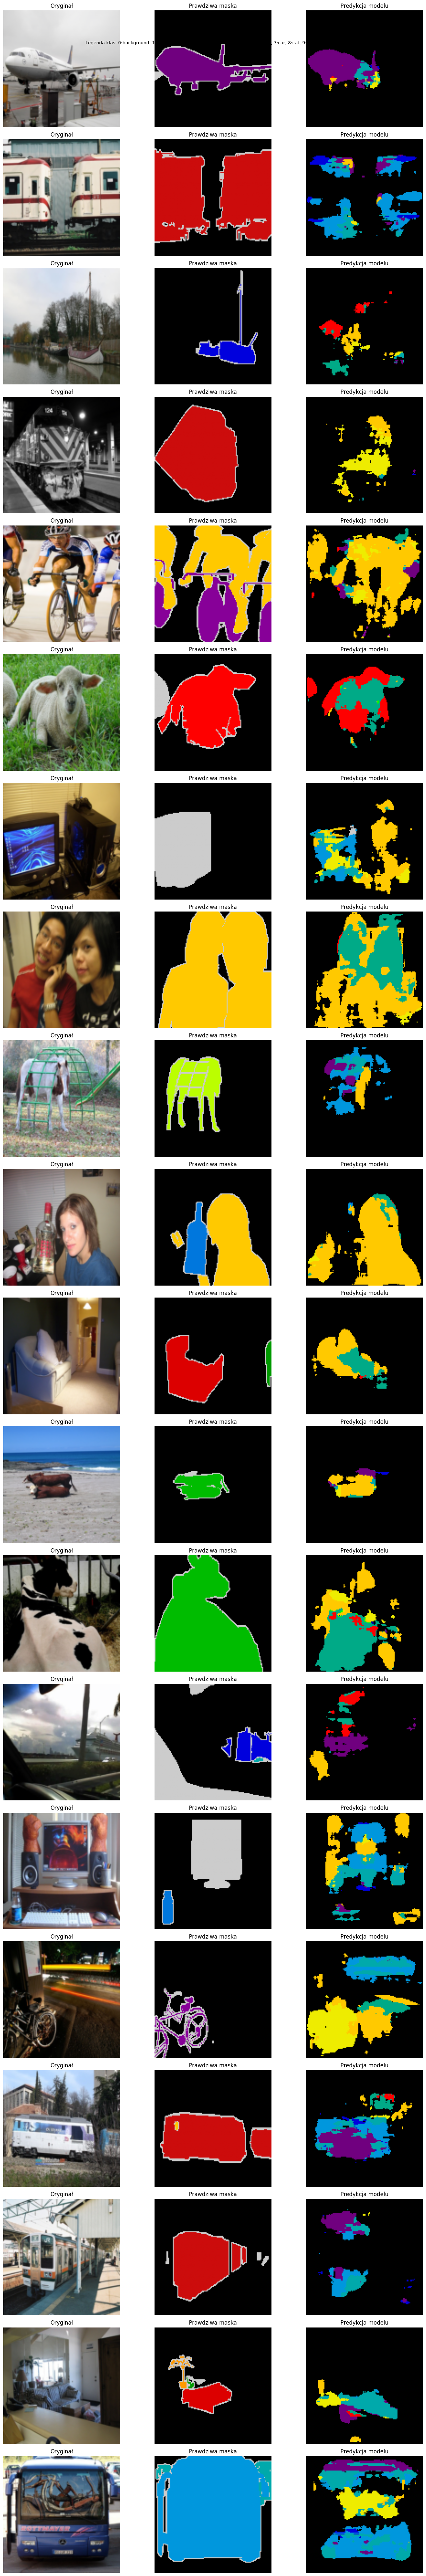

In [27]:


VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
def visualize_predictions(model, dataset, device, num_samples=20):
    model.eval()
    num_samples = min(num_samples, len(dataset))
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples), squeeze=False)

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)


# Wyniki
## Ogólnie
### Metryki
`train_loss` maleje.
`val_pixel_acc` ma sufit przy ~0.73 i nie polepsza się
### Refleksje transformacji
dodanie *data augmentation* oraz *osłabienie kary na maskę tła* **znacznie poprawiło** działanie modelu (pozdro Kamil).
### Zwięszanie base_channels
16->32->64 maska staje się coraz lepsza w rozpoznawaniu przedmiotów.
Co ciekawe: 64->128 produkują **identyczne** maski.
Uważam iż może to być sygnał przetrenowania sieci. Następnymi krokami mogłoby być:
* zwiększenie rund iteracji po datasecie `epochs`
* dalsze dostrajanie wagi tła.
* znaleźć ciekawsze transformacje danych.
Jednakże trzeba liczyć się także z ewentuanością, że dataset jest zbyt mały co prowadzi do underfittingu modelu.
Może to także być sygnał, aby dokonać upgrade'u architektury `SmallU-Net` na `U-Net`

## Maski
W skrócie, 
### base_channels = 16
![base_channels=16](model-masks/16.png)
### base_channels = 32
![base_channels=32](model-masks/32.png)
### base_channels = 64
![base_channels=64](model-masks/64.png)

### base_channels = 128
![base_channels=128](model-masks/128.png)
